**NAME   :** SASI KUMAR B

**REG NO  :** 212223060252

**EXP NO  :** 3

**EXP NAME:** PULSE CODE MODULATION AND DELTA MODULATION

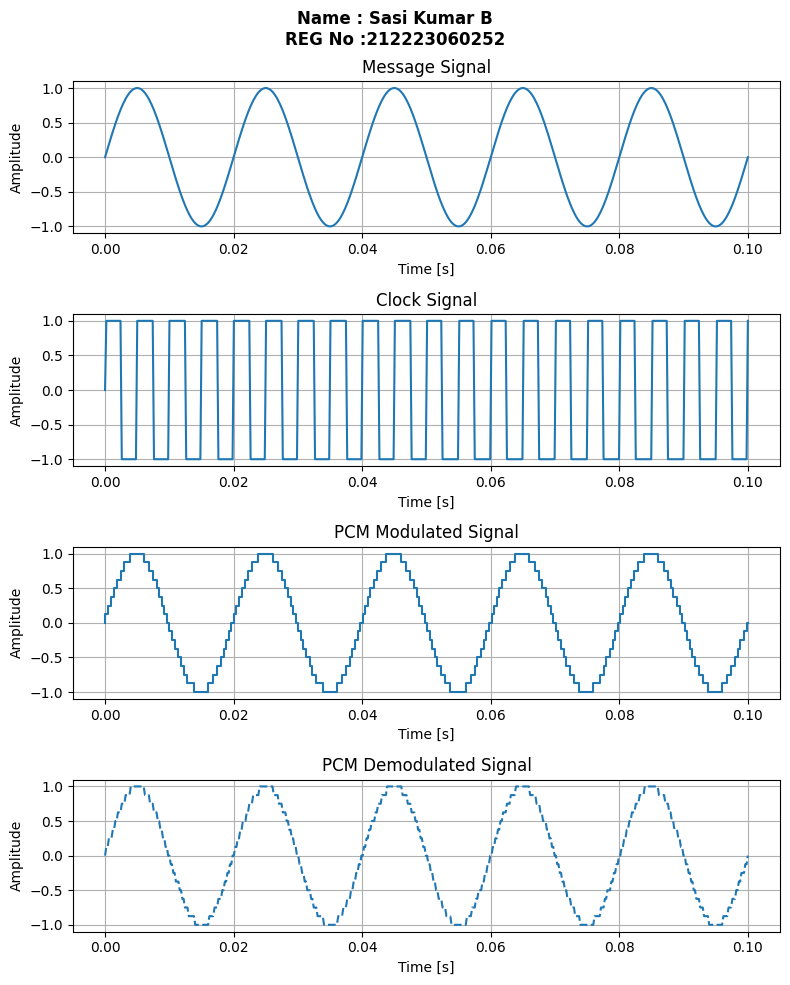

In [2]:
#Pulse code modulation

import numpy as np
import matplotlib.pyplot as plt

sampling_rate = 5000
frequency = 50
duration = 0.1
quantization_levels = 16

t = np.linspace(0, duration, int(sampling_rate*duration))

msg_signal = np.sin(2*np.pi*frequency*t)
clk_signal = np.sign(np.sin(2*np.pi*200*t))

quantization_step = (msg_signal.max()-msg_signal.min())/quantization_levels
quantized_signal = np.round(msg_signal/quantization_step)*quantization_step

plt.figure(figsize=(8,10))

plt.subplot(4,1,1)
plt.plot(t, msg_signal)
plt.suptitle("Name : Sasi Kumar B\nREG No :212223060252", fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.title("Message Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(4,1,2)
plt.plot(t, clk_signal)
plt.title("Clock Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(4,1,3)
plt.step(t, quantized_signal)
plt.title("PCM Modulated Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(4,1,4)
plt.plot(t, quantized_signal,'--')
plt.title("PCM Demodulated Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

**NAME   :** SASI KUMAR B

**REG NO  :** 212223060252

**EXP NO  :** 3

**EXP NAME:** PULSE CODE MODULATION AND DELTA MODULATION

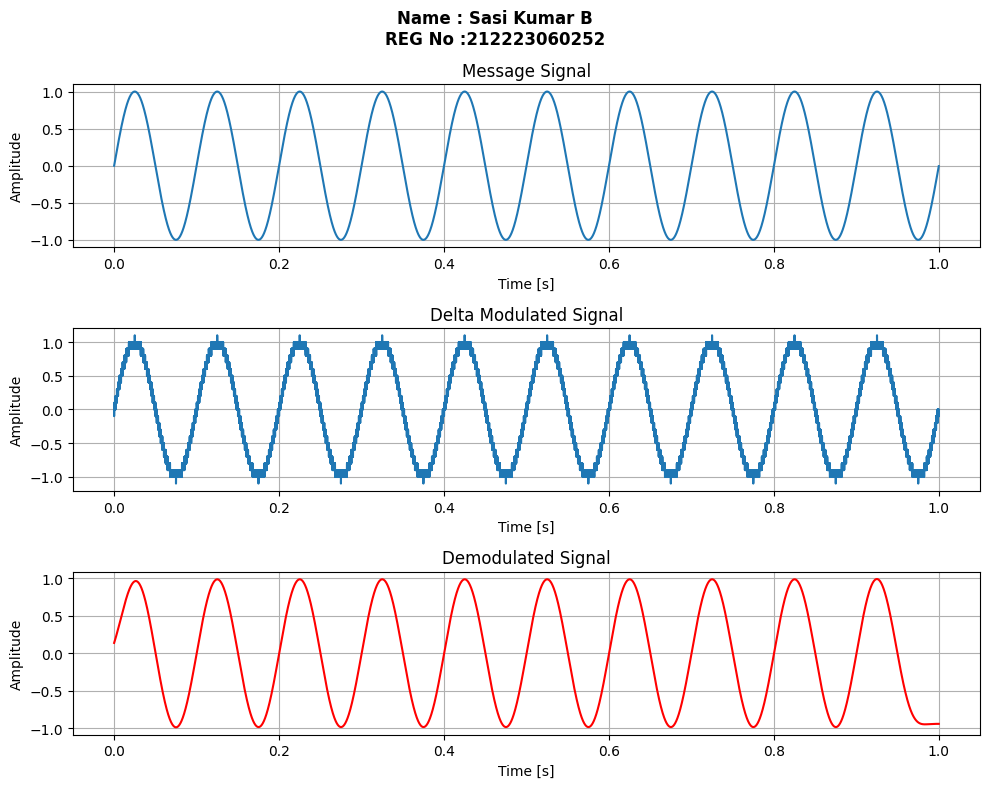

In [1]:
#Delta modulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Parameters
fs = 10000
f = 10
T = 1
delta = 0.1

t = np.arange(0, T, 1/fs)
message_signal = np.sin(2*np.pi*f*t)

# Delta Modulation
encoded_signal = []
dm_output = [0]
prev_sample = 0

for sample in message_signal:
    if sample > prev_sample:
        encoded_signal.append(1)
        prev_sample += delta
    else:
        encoded_signal.append(0)
        prev_sample -= delta
    dm_output.append(prev_sample)

# Delta Demodulation
demodulated_signal = [0]
for bit in encoded_signal:
    demodulated_signal.append(
        demodulated_signal[-1] + delta if bit else demodulated_signal[-1] - delta
    )

# Low-pass filtering
b, a = butter(4, 20/(0.5*fs))
filtered_signal = filtfilt(b, a, demodulated_signal)

# Plots
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, message_signal)
plt.suptitle("Name : Sasi Kumar B\nREG No :212223060252", fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.title("Message Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(3,1,2)
plt.step(t, dm_output[:-1])
plt.title("Delta Modulated Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")


plt.subplot(3,1,3)
plt.plot(t, filtered_signal[:-1], 'r')
plt.title("Demodulated Signal")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")


plt.tight_layout()
plt.show()